In [8]:
import numpy as np
from matplotlib import pyplot as plt
path = 'C:/Users/alexv/Desktop/Università/astrostat/astrostatistics_bicocca_2025/solutions/formationchannels.npy'
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2

## Model comparison
In this excercise our goal is to find the optimal gaussian mixture model that fits the distribuition of Black hole masses. To do so, we will use the Akaike Information Criterion (AIC) as a model selection metric to identify the most suitable number of Gaussian components:
$$ \mathrm{AIC}_M \equiv -2\ln[L^0(M)] + 2k + \frac{2k(k+1)}{N-k-1}, $$
with $ ln[L^0(M)$ the maximum likelihood of the model M, k and N are respectively the number of parameters and  data points.
The AIC balances model fit and complexity by penalizing models with more parameters, especially when they are not well constrained by the data.

The preferred model is the one with the lowest AIC, indicating an optimal trade-off between goodness-of-fit and simplicity.

Text(0.5, 0, 'Black Hole mass $[M_\\odot]$')

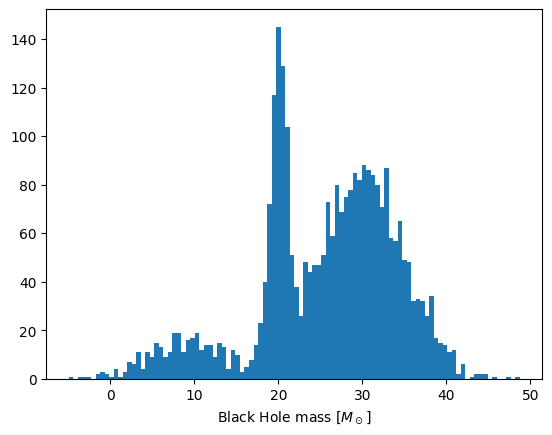

In [9]:
#Plot the distribuition of the data
data = np.load(path)
N = 10
plt.hist(data, bins = 100)
plt.xlabel(r"Black Hole mass $[M_\odot]$")

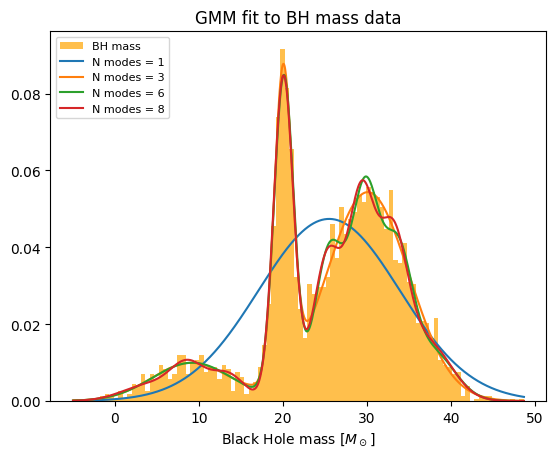

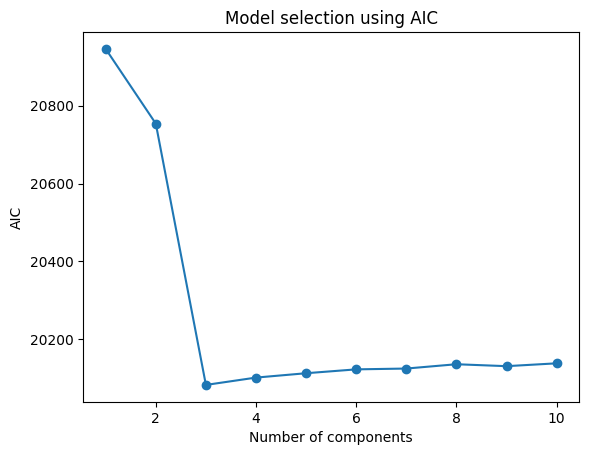

In [26]:

AIC = []
log_gaussians_arr = []

for i in range(1, N + 1):
    mod = GaussianMixture(n_components=i)
    mod.fit(data)
    AIC.append(mod.aic(data))
    
    xgrid = np.linspace(np.min(data), np.max(data), 1000).reshape(-1, 1)
    log_gaussians_arr.append(mod.score_samples(xgrid))  # salva log-densità

# Plot of various gaussians
idx = [0, 2, 5, 7] 

plt.hist(data, bins=100, alpha=0.7, density=True, color='orange', label='BH mass')

for i in idx:
    plt.plot(xgrid, np.exp(log_gaussians_arr[i]), label=f'N modes = {i+1}')

plt.legend(prop={'size': 8}, loc='upper left')
plt.title("GMM fit to BH mass data")
plt.xlabel(r"Black Hole mass $[M_\odot]$")
plt.show()

# Plot AIC
n = np.arange(1, N + 1)
plt.plot(n, AIC, marker='o')
plt.xlabel("Number of components")
plt.ylabel("AIC")
plt.title("Model selection using AIC")
plt.show()


The AIC yields to the gaussian mixture with 3 modes!

3


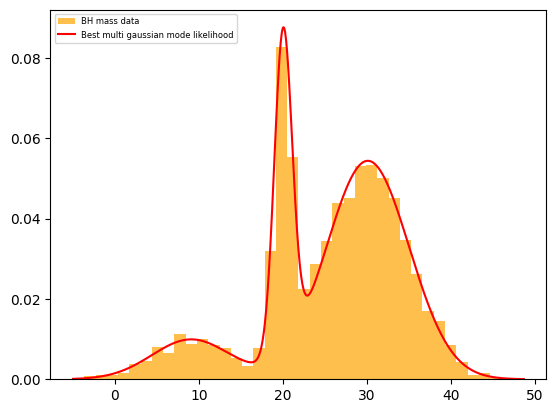

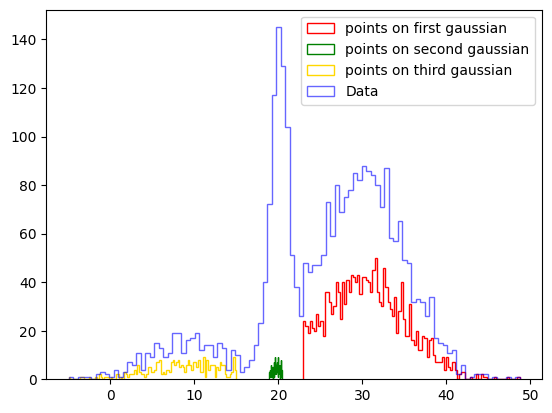

In [33]:
#Taking the loglikelihood with the best number of modes:
idx_min = np.argmin(AIC)+1
print(idx_min)
temp = GaussianMixture(idx_min)
temp.fit(data)
xgrid = np.linspace(np.min(data),np.max(data), 1000).reshape(-1,1)
log_likelihood = temp.score_samples(xgrid)

#Plot of best model superimposed over the data
plt.hist(data, bins = 40, alpha = 0.7, label = 'BH mass data', color= 'orange', density = True)
plt.plot(xgrid, np.exp(log_likelihood), label = 'Best multi gaussian mode likelihood', color = 'red')
plt.legend(prop = {'size': 6} ,loc= 'upper left')
plt.show()
probs = temp.predict_proba(data)

#Check for each point what is the probability of belonging to one of the three modes.
mode_assignments = np.argmax(probs, axis=1)
first_mode = data[(mode_assignments == 0) & (probs[:,0]>0.9)]
second_mode = data[(mode_assignments == 1) & (probs[:, 1]>0.9)]
third_mode = data[(mode_assignments == 2) & (probs[:,2]>0.9)]
plt.hist(first_mode, bins = 100, color = 'red', histtype='step', alpha = 1, label = 'points on first gaussian')
plt.hist(second_mode, bins = 100, color = 'green',histtype='step', alpha = 1, label = 'points on second gaussian')
plt.hist(third_mode, bins = 100, color = 'gold', histtype='step',alpha = 1, label = 'points on third gaussian')
plt.hist(data, bins = 100, color = 'blue', histtype='step',alpha = 0.6, label = 'Data')
plt.legend()
plt.show()